In [65]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
datadir0  ='/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_Trelax/'
datadir1 = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_Trelax/Data/'
plotsdir = '//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_Trelax/Plots/'
#dataout  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Plotting/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current recursion limit: 6000


In [66]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]
    
def tolerant_mean(arrs):
    lens = [len(i) for i in arrs]
    #print(lens)
    arr = np.ma.empty((np.max(lens),len(arrs)))
    arr.mask = True
    for idx, l in enumerate(arrs):
        #print(l)
        arr[:len(l),idx] = l
    return arr.mean(axis = -1), arr.std(axis=-1)
# Example function for exponential decay

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

def add_segment(mp_index, t, mean, std):
    """Store one contiguous time segment for a given MP."""
    t = np.asarray(t, dtype=float).copy()
    mean = np.asarray(mean, dtype=float).copy()
    std  = np.asarray(std, dtype=float).copy()
    n = min(len(t), len(mean), len(std))
    if n == 0:
        return
    stress_segments[mp_index].append((t[:n], mean[:n], std[:n]))

def write_mp_file(mp_index, mp_value):
    """Concatenate segments, sort by time, and write a single file."""
    if len(stress_segments[mp_index]) == 0:
        print("No segments for MP", mp_value)
        return

    t_all   = np.concatenate([seg[0] for seg in stress_segments[mp_index]])
    mean_all= np.concatenate([seg[1] for seg in stress_segments[mp_index]])
    std_all = np.concatenate([seg[2] for seg in stress_segments[mp_index]])

    order = np.argsort(t_all)
    df = pandas.DataFrame({
        "Time":      t_all[order],
        "AvStress":  mean_all[order],
        "StdStress": std_all[order],
    })

    # OPTIONAL: if you might have duplicate times (overlap), you can average them:
    # df = df.groupby("Time", as_index=False).agg({"AvStress":"mean", "StdStress":"mean"})

    fname = outdir / f"Stress_MP{mp_value}.dat"
    df.to_csv(fname, sep=" ", index=False, float_format="%.8g")
    print("Wrote", fname)



In [67]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
ClrsRiciChosenHalf = ["#7883acff","#73457aff","#b25268ff","#d49995ff"]


In [68]:
def plot_stress_from_files_with_fit(
    MPs,
    clrs,
    outdir,
    ax,
    time_scale=1e5,

    # --- fitting window in *raw Time units* (same as stored in file) ---
    fit_t_start=6.0e5,      # ~ tEndRel in your original script
    fit_t_end=1.101e6,      # ~ tEndRel + 5e5 in your original script

    # plot styling
    lw=2.0,
    alpha_band=0.30,
    fit_lw=1.5,
    fit_ls=":",
    fit_color="black",

    # labeling / output
    label_fn=None,          # optional: label_fn(mp_index)->string for mean curve
    annotate_tau=False,     # annotate tau on plot near fit curve
    annotate_fmt=r"$\tau={:.2g}$",
):
    """
    Reads Stress_MP*.dat (columns: Time AvStress StdStress),
    plots mean with shaded ±std band, and fits exp decay on the mean curve.

    Returns:
        taus: np.array of fitted taus (np.nan if fit failed)
    """
    outdir = Path(outdir)
    taus = np.full(len(MPs), np.nan, dtype=float)

    for x, mp in enumerate(MPs):
        f = outdir / f"Stress_MP{mp}.dat"
        if not f.exists():
            print("Missing:", f)
            continue

        df = pandas.read_csv(f, sep=r"\s+", engine="python")

        # numeric + sorted
        t   = pandas.to_numeric(df["Time"], errors="coerce").to_numpy(dtype=float)
        mu  = pandas.to_numeric(df["AvStress"], errors="coerce").to_numpy(dtype=float)
        sig = pandas.to_numeric(df["StdStress"], errors="coerce").to_numpy(dtype=float)

        mask = np.isfinite(t) & np.isfinite(mu) & np.isfinite(sig)
        t, mu, sig = t[mask], mu[mask], sig[mask]

        order = np.argsort(t)
        t, mu, sig = t[order], mu[order], sig[order]

        # plot mean ± std
        tx = t / time_scale
        lab = None if label_fn is None else label_fn(x)

        ax.plot(tx, mu, color=clrs[x], linewidth=lw, label=lab)
        ax.fill_between(tx, mu - sig, mu + sig, color=clrs[x], alpha=alpha_band)

        # ---------------- fit exp decay on mean ----------------
        fit_mask = (t >= fit_t_start) & (t <= fit_t_end)
        if np.count_nonzero(fit_mask) < 10:
            print(f"MP={mp}: not enough points in fit window [{fit_t_start:g},{fit_t_end:g}]")
            continue

        t_fit_abs = t[fit_mask]
        y_fit     = mu[fit_mask]

        # make time relative to window start (like your TimeFit)
        t_fit = t_fit_abs - t_fit_abs[0]

        # initial guesses (same spirit as yours)
        A0   = y_fit[0] - y_fit[-1]
        tau0 = (t_fit[-1] - t_fit[0]) / 5.0 if (t_fit[-1] > t_fit[0]) else 1.0
        C0   = y_fit[-1]
        p0   = [A0, tau0, C0]

        try:
            params, cov = curve_fit(exp_decay, t_fit, y_fit, p0=p0, maxfev=20000)
            A, tau, C = params
            taus[x] = tau
            print(f"MP={mp}: fit -> A={A:.3g}, tau={tau:.3g}, C={C:.3g}")

            # overlay fitted curve on top of mean curve
            y_model = exp_decay(t_fit, *params)
            ax.plot(
                (t_fit_abs / time_scale),
                y_model,
                linestyle=fit_ls,
                color=fit_color,
                linewidth=fit_lw,
                zorder=5
            )

            if annotate_tau:
                # place annotation near the end of the fit curve
                ax.text(
                    (t_fit_abs[-1] / time_scale),
                    y_model[-1],
                    annotate_fmt.format(tau),
                    fontsize=9,
                    ha="left",
                    va="center",
                    color=fit_color
                )

        except Exception as e:
            print(f"MP={mp}: fit failed ({type(e).__name__}): {e}")

    return taus

In [69]:
TLifeDenseControl = [1099864214.852721, 647244015.958075, 302691299.9283709, 193380543.86555687, 125399124.23642237, 72382977.98185535, 54627694.158685945]
TLifeDenseControlSTD = [44699278.24732293,  22813613.258780956,  16283695.86598525, 10284609.004496682, 5920680.203341648, 7337765.993784864, 1091191.1142829212]
Taus=[16401.45832306 , 10454.5752332   ,4405.37357503 , 3018.91964483,  2236.18922721 , 1977.03609215 , 1452.91837506]
Taus_std=[604.8449615   , 49.68744122 , 935.75454548 , 288.93094047 , 414.79754408 , 340.46029844,  677.22418629]

MP=1.0: fit -> A=0.51, tau=1.6e+03, C=-0.095
MP=0.81: fit -> A=0.518, tau=1.99e+03, C=-0.102
MP=0.6: fit -> A=0.539, tau=2.18e+03, C=-0.114
MP=0.39: fit -> A=0.642, tau=3.04e+03, C=-0.136
MP=0.27: fit -> A=0.636, tau=4.44e+03, C=-0.159
MP=0.12: fit -> A=1.15, tau=1.05e+04, C=-0.212
MP=0.06: fit -> A=1.65, tau=1.64e+04, C=-0.249


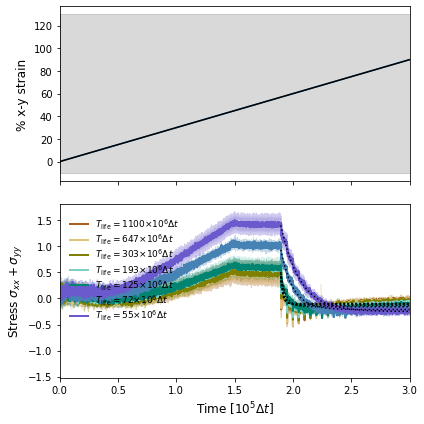

In [70]:
MPs = "1.0 0.81 0.6 0.39 0.27 0.12 0.06".split() # 0.18 0.27 0.6 0.81 0.09 0.18 0.27 0.6 0.81 
figNICE,axNICE=plt.subplots(2,1,figsize = (6,6))
outdir = Path(datadir0) / "Data"
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
# Optional: if you want the same legend labels you used before
# (requires you already have TLifeDenseControl defined in scope)
def my_label_fn(x):
    return (r'$T_{\mathrm{life}} = $'
            + str(np.round(np.divide(TLifeDenseControl[x], 1e6)).astype(int))
            + r'$\times10^6\Delta t$')


taus = plot_stress_from_files_with_fit(
    MPs=MPs,
    clrs=clrs,
    outdir=outdir,
    ax=axNICE[1],
    time_scale=1e5,
    fit_t_start=1.196e5+0.7e5,
    fit_t_end=1.196e5+0.7e5+1.5e5,
    label_fn=my_label_fn,     # or None
    annotate_tau=False        # set True if you want τ printed on the plot
)
text1 = 'Equilibrate'
text2 = 'i. Measure\n   monomer\n   turnover'
text3 = 'ii. Apply strain'
text4 = 'iii. Initial relaxation: \n     no turnover'
text5 = 'Add monomers'
text6 = 'iv. Full relaxation: \n     with turnover'


Times = [-3,0,4,6,10]
Strains = [0,0,120,120,120]
axNICE[0].plot(Times,Strains)
t_Eq,t_MT,t_strain,t_InitRel,t_FullRel = -3, 0, 4, 5, 10

axNICE[0].plot(Times,Strains,linestyle = '-',color = 'black')
axNICE[0].fill_between([-5,t_Eq],[-10,-10],[130,130],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_Eq,t_MT],[-10,-10],[130,130],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_MT,t_strain],[-10,-10],[130,130],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_strain,t_InitRel],[-10,-10],[130,130],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_InitRel,t_FullRel],[-10,-10],[130,130],alpha = 0.15,color = 'black')

#axNICE[0].text(t_Eq+1.,40,text2,color = 'grey',fontsize = 11)
#axNICE[0].text(t_MT+0.01,100,text3,color = 'black',fontsize = 11)
#axNICE[0].text(t_strain+0.01,40,text4,color = 'grey',fontsize = 11)
#axNICE[0].text(t_InitRel+0.02,5,text6,color = 'black',fontsize = 11)

axNICE[0].set_ylabel("% x-y strain",fontsize =12)
axNICE[1].set_ylabel("Stress $\sigma_{xx}+\sigma_{yy}$",fontsize = 12)
axNICE[1].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[0].set_xticklabels([])
axNICE[1].legend(frameon=False,loc = [0.02,0.3],fontsize = 9,labelspacing=0.12)
axNICE[1].set_xlim([0,3])
axNICE[0].set_xlim([0,3])
#axNICE[1].set_ylim([-0.5,3])
figNICE.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[ 1596.15987502  1993.89076191  2178.85525959  3036.48472977
  4437.07769117 10454.38907294 16438.51406402]


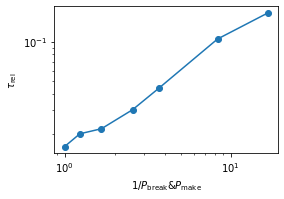

In [71]:
print(taus)
MPsV = [1.0,0.81,0.6,0.39,0.27,0.12,0.06]
fig,ax = plt.subplots(1,figsize = (4.,2.7))
ax.plot(np.divide(1,MPsV),np.divide(taus,1e5),marker = 'o')
#for i in range(3):
#    ax.plot(np.divide(1,MPsV),np.divide(Taus[:,i],1e5),marker = 'o',label = "seed"+str(i))
ax.set_xlabel(r"$1/P_{\mathrm{break}} & P_{\mathrm{make}}$")
ax.set_ylabel(r"$\tau_{\mathrm{rel}}$")
ax.legend(frameon=False)
ax.set_xscale('log')
ax.set_yscale('log')



MP=0.03: fit -> A=2.53, tau=3.28e+04, C=-0.262
MP=0.12: fit -> A=1.16, tau=1.04e+04, C=-0.212
MP=0.27: fit -> A=0.66, tau=4.38e+03, C=-0.159


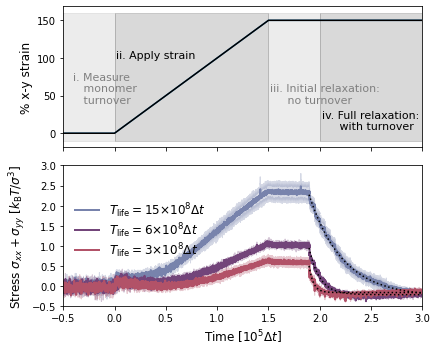

In [73]:
# ---------------- Example usage ----------------
# You already have figNICE, axNICE = plt.subplots(2,1,...)
# and MPs, clrs, datadir0 defined.
MPs = "0.03 0.12 0.27".split() # 0.03 0.06 0.09 0.18 0.27 0.6 0.81
figNICE,axNICE=plt.subplots(2,1,figsize = (6,5))
outdir = Path(datadir0) / "Data"
clrs = ClrsRiciChosenHalf
TLifeDenseControl_this = [1527057046.222454,634918079.152642,302691299.9283709]
# Optional: if you want the same legend labels you used before
# (requires you already have TLifeDenseControl defined in scope)
def my_label_fn(x):
    return (r'$T_{\mathrm{life}} = $'
            + str(np.round(np.divide(TLifeDenseControl_this[x], 1e8)).astype(int))
            + r'$\times10^8\Delta t$')


taus2 = plot_stress_from_files_with_fit(
    MPs=MPs,
    clrs=clrs,
    outdir=outdir,
    ax=axNICE[1],
    time_scale=1e5,
    fit_t_start=1.195e5+0.7e5,
    fit_t_end=1.195e5+0.7e5+1.5e5,
    label_fn=my_label_fn,     # or None
    annotate_tau=False        # set True if you want τ printed on the plot
)
text1 = 'Equilibrate'
text2 = 'i. Measure\n   monomer\n   turnover'
text3 = 'ii. Apply strain'
text4 = 'iii. Initial relaxation: \n     no turnover'
text5 = 'Add monomers'
text6 = 'iv. Full relaxation: \n     with turnover'


Times = [-1,0,1.5,2,10]
Strains = [0,0,150,150,150]
axNICE[0].plot(Times,Strains)
t_Eq,t_MT,t_strain,t_InitRel,t_FullRel = -1, 0, 1.5, 2.0, 10

axNICE[0].plot(Times,Strains,linestyle = '-',color = 'black')
axNICE[0].fill_between([-5,t_Eq],[-10,-10],[160,160],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_Eq,t_MT],[-10,-10],[160,160],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_MT,t_strain],[-10,-10],[160,160],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_strain,t_InitRel],[-10,-10],[160,160],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_InitRel,t_FullRel],[-10,-10],[160,160],alpha = 0.15,color = 'black')

axNICE[0].text(t_Eq+0.6,40,text2,color = 'grey',fontsize = 11)
axNICE[0].text(t_MT+0.01,100,text3,color = 'black',fontsize = 11)
axNICE[0].text(t_strain+0.01,40,text4,color = 'grey',fontsize = 11)
axNICE[0].text(t_InitRel+0.02,5,text6,color = 'black',fontsize = 11)

axNICE[0].set_ylabel("% x-y strain",fontsize =12)
axNICE[1].set_ylabel(r"Stress $\sigma_{xx}+\sigma_{yy}~ [k_{\mathrm{B}}T/\sigma^3]$",fontsize = 12)
axNICE[1].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[0].set_xticklabels([])
axNICE[1].legend(frameon=False,loc = [0.02,0.3],fontsize = 12,labelspacing=0.12)
axNICE[1].set_xlim([-0.5,3])
axNICE[0].set_xlim([-0.5,3])
axNICE[1].set_ylim([-0.5,3])

figNICE.tight_layout()
figNICE.savefig(plotsdir + 'Stress_FromData.png',dpi = 300)


In [74]:

TLifeDenseControlSTD = TLifeDenseControlSTD[::-1] 
TLifeDenseControl = TLifeDenseControl[::-1]
Taus_Std =Taus_std[::-1]
Taus_Av = Taus[::-1] 

#from : Scratch/Collagen/RiccyProject/Revision2/Stretch-AddDenseControl/Plotting/PlottingStress_CLEAN.ipynb


Gradient is 1.45588270942949e-05


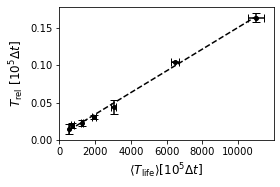

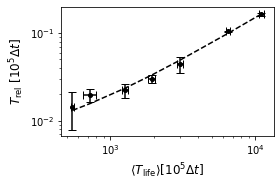

In [80]:
fig,ax = plt.subplots(1,figsize = (4.,2.7))
x1,y1 = np.array(np.divide(TLifeDenseControl,10**5)),np.array(np.divide(Taus_Av,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
ax.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
#ax.text(15,0.6,text,color = 'black',fontsize = 12)
#---- log-log axis---#
#ax.set_xscale('log')
#ax.set_yscale('log')
#ax.set_xticks([0,200,400,600],['0','200','400','600'])
#ax.set_yticks([0,0.2,0.4,0.6,0.8],['0','0.2','0.4','0.6','0.8'])

fig.tight_layout()
fig.savefig(plotsdir + 'MasterTlifeTrelax.png',dpi = 300)

fig,ax = plt.subplots(1,figsize = (4.,2.7))
x1,y1 = np.array(np.divide(TLifeDenseControl,10**5)),np.array(np.divide(Taus_Av,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
print("Gradient is",m1)
ax.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 1.5\cdot 10^{-5}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
#ax.text(30,0.3,text,color = 'black',fontsize = 12)
#---- log-log axis---#
ax.set_xscale('log')
ax.set_yscale('log')


fig.tight_layout()
fig.savefig(plotsdir + 'MasterTlifeTrelax_log.png',dpi = 300)
